# 22: the image at scale

Everything above the basis is one linear statistic, `S = Phi^T (w y)` and
`G = Phi^T diag(w) Phi`, additive over sample sets. That is the whole claim
of this notebook: a chunked, merged, streamed or parallel fit is the same
computation as the resident one, at a measured cost. Claims:

1. Merging chunk images reproduces the whole-data fit: order of merge does
   not matter beyond floating-point rounding, and a missing chunk costs
   data, not an error, the fit it leaves staying within one standard error
   of the whole-record one. False if the merged fit disagrees with the
   whole-data one by more than rounding, if reordering the merge moves the
   coefficients by more than 1e-10 relative, or if dropping one of eight
   shards moves a fitted parameter by as much as one standard error of the
   whole-record fit.
2. The additive reduce stays accurate in float64 regardless of chunk count;
   naive float32 degrades on a high-dynamic-range integrand, and a
   Kahan-compensated float32 sum narrows what float32 loses across chunks
   without reaching float64. False if float32's error does not exceed
   float64's, or if the compensated sum is ever worse than the naive one
   at the same chunk count.
3. `ImageStream` holds memory flat as the record grows; the resident route
   does not. False if the streamed peak does not stay far below the
   resident one at the larger record length, or if it grows nearly as fast
   as the resident peak between the two lengths.
4. `fit_many` on processes beats a serial loop; on threads it does not,
   the GIL owning the absence of a gain. False if processes do not beat
   serial, or if a thread pool shows a speed-up the repeats support.
5. A GPU projection is a win only once the data is already on the device:
   with the host transfer counted it does not beat a single BLAS thread at
   any width measured here. Where no GPU backend is installed the width
   sweep still runs and the device columns are empty.
6. A structured fit trained on half a record and extrapolated over the
   rest holds up; a polynomial surrogate trained the same way does not,
   at any degree tried, while on the training half the two are apart
   only at the lowest degrees. False if a surrogate of any degree tried
   extrapolates within a factor two of the structured fit, or if at the
   structured fit's own order its in-sample error does not exceed the
   structured fit's.

A cell that measures time runs on a shared machine: every timing below is
a median or a minimum over at least five repeats, with the spread printed
beside it, and a ratio is stated to no more digits than the repeats agree
on. The run holds OPENBLAS_NUM_THREADS and OMP_NUM_THREADS at 1, which the
setup cell prints, so the thread pool of section 4 competes with no BLAS
threads inside the fits.

In [1]:
import os
import math
import time

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from threadpoolctl import threadpool_info, threadpool_limits

from dtfit.image import (
    Image, ImageStream, Original, FittingProblem, fit_many, make_basis, u_of,
)
from dtfit.image import fit as dfit
from dtfit_experimental.study import notebook
from dtfit_experimental.study.cost import peak_memory

notebook.plain_warnings()
plt.rcParams["figure.dpi"] = 110

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"

N = 100_000 if QUICK else 1_000_000
N_CHUNKS = 8
ORDER = 6
DOMAIN = (0.0, 1.0)
CHUNK_COUNTS = [1, 4, 64] if QUICK else [1, 4, 16, 64, 256, 1024]
MEM_LENGTHS = [20_000, 100_000] if QUICK else [200_000, 1_000_000]
MEM_CHANNELS = 32
N_PROBLEMS = 40 if QUICK else 200
TIMING_REPS = 2 if QUICK else 5
GPU_WIDTHS = [500, 2000] if QUICK else [500, 2000, 8000]
GPU_N = 5_000 if QUICK else 20_000
GPU_ORDER = 17
TRAP_DEGREES = [2, 4, 8] if QUICK else [2, 3, 4, 5, 6, 8]

blas_env = max((p["num_threads"] for p in threadpool_info()
                if p["user_api"] == "blas"), default=0)
print(f"QUICK={QUICK} N={N} MEM_LENGTHS={MEM_LENGTHS} N_PROBLEMS={N_PROBLEMS}")
print(f"OPENBLAS_NUM_THREADS={os.environ.get('OPENBLAS_NUM_THREADS', 'unset')} "
      f"OMP_NUM_THREADS={os.environ.get('OMP_NUM_THREADS', 'unset')}, "
      f"numpy's BLAS reports {blas_env} thread(s)")

QUICK=False N=1000000 MEM_LENGTHS=[200000, 1000000] N_PROBLEMS=200
OPENBLAS_NUM_THREADS=1 OMP_NUM_THREADS=1, numpy's BLAS reports 1 thread(s)


## 1. Merging chunk images

An `Original` imaged whole, or imaged in `N_CHUNKS` chunks and merged with
`Image.merge`, is the same additive statistic either way, whatever order
the chunks arrive in. The record is a noisy exponential decay; the model
fit on it recovers `a` and `b`. The wall times in the table are the image
route's own, whole against chunked; no other accumulator is measured here.

In [2]:
rng = np.random.default_rng(0)
x = np.linspace(*DOMAIN, N)
A_TRUE, B_TRUE = 2.0, 3.0
y = A_TRUE * np.exp(-B_TRUE * x) + rng.normal(0.0, 0.01, N)

edges = np.linspace(0, N, N_CHUNKS + 1).astype(int)


def image_whole():
    return Image.of(Original(x, y, domain=DOMAIN), "legendre", ORDER)


def image_chunked():
    chunks = [
        Image.of(Original(x[edges[i]:edges[i + 1]], y[edges[i]:edges[i + 1]],
                          domain=DOMAIN), "legendre", ORDER)
        for i in range(N_CHUNKS)
    ]
    merged = chunks[0]
    for c in chunks[1:]:
        merged = merged.merge(c)
    return chunks, merged


def repeat(fn, reps=TIMING_REPS):
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        out = fn()
        times.append(time.perf_counter() - t0)
    return out, float(np.median(times)), float(np.min(times)), float(np.max(times))


whole, t_whole, t_whole_lo, t_whole_hi = repeat(image_whole)
(chunks, merged), t_chunked, t_chunked_lo, t_chunked_hi = repeat(image_chunked)

reversed_merged = chunks[-1]
for c in reversed(chunks[:-1]):
    reversed_merged = reversed_merged.merge(c)

r_whole = dfit("a*exp(-b*t)", whole, "t", p0=[1.0, 1.0])
r_merged = dfit("a*exp(-b*t)", merged, "t", p0=[1.0, 1.0])
r_reversed = dfit("a*exp(-b*t)", reversed_merged, "t", p0=[1.0, 1.0])

beta_rel_merge = float(np.max(np.abs(whole.beta - merged.beta) / np.abs(whole.beta)))
beta_rel_order = float(np.max(np.abs(merged.beta - reversed_merged.beta) / np.abs(merged.beta)))
param_rel_merge = float(np.max(np.abs(r_whole.coeffs - r_merged.coeffs) / np.abs(r_whole.coeffs)))
param_rel_order = float(np.max(np.abs(r_merged.coeffs - r_reversed.coeffs) / np.abs(r_merged.coeffs)))

timing = {"whole median (s)": t_whole, "whole min (s)": t_whole_lo,
          "whole max (s)": t_whole_hi, "chunked median (s)": t_chunked,
          "chunked min (s)": t_chunked_lo, "chunked max (s)": t_chunked_hi,
          "timing reps": TIMING_REPS}
merge_exactness = pd.DataFrame([
    {"condition": "8 chunks merged in order vs whole-data image",
     "max coefficient rel diff": beta_rel_merge,
     "max parameter rel diff": param_rel_merge, **timing},
    {"condition": "chunks merged in reverse order vs forward order",
     "max coefficient rel diff": beta_rel_order,
     "max parameter rel diff": param_rel_order, **timing},
])
merge_exactness

,condition,max coefficient rel diff,max parameter rel diff,whole median (s),whole min (s),whole max (s),chunked median (s),chunked min (s),chunked max (s),timing reps
0,8 chunks merged in order vs whole-data image,4.922445e-14,2.072469e-15,0.044899,0.043893,0.086276,0.077732,0.075222,0.079478,5
1,chunks merged in reverse order vs forward order,1.158915e-12,4.441005e-16,0.044899,0.043893,0.086276,0.077732,0.075222,0.079478,5


In [3]:
missing = chunks[0]
for c in chunks[1:-1]:
    missing = missing.merge(c)
r_missing = dfit("a*exp(-b*t)", missing, "t", p0=[1.0, 1.0])

se_whole = r_whole.stderr()
truth = {"a": A_TRUE, "b": B_TRUE}
shard_dropout = pd.DataFrame([
    {"parameter": name,
     "true": truth[name],
     "whole-record fit": r_whole.params[name],
     "7 of 8 shards": r_missing.params[name],
     "whole-record standard error": se_whole[name],
     "shift (standard errors)":
         abs(r_missing.params[name] - r_whole.params[name]) / se_whole[name],
     "whole-record error against true": abs(r_whole.params[name] - truth[name]),
     "7 of 8 error against true": abs(r_missing.params[name] - truth[name])}
    for name in r_whole.params
])
shard_dropout


,parameter,true,whole-record fit,7 of 8 shards,whole-record standard error,shift (standard errors),whole-record error against true,7 of 8 error against true
0,a,2.0,1.999990,1.999991,0.000035,0.009125,0.000010,0.000009
1,b,3.0,2.999924,2.999925,0.000077,0.017548,0.000076,0.000075


In [4]:
# fails if the merged fit does not reproduce the whole-data one to rounding
assert beta_rel_merge < 1e-10
assert param_rel_merge < 1e-10
# fails if the merge order moves the coefficients by more than 1e-10 relative
assert beta_rel_order < 1e-10
max_shift_se = float(shard_dropout["shift (standard errors)"].max())
# fails if the fit on the remaining shards moves a parameter by one standard
# error of the whole-record fit: merging only the first shard of eight moves
# b by 3.0 of them
assert max_shift_se < 1.0
# fails if the merge lost samples beyond the dropped shard's own, as it does
# when the first shard is left out of it too
assert missing.n == int(edges[-2])
chunk_cost_lo = t_chunked_lo / t_whole_hi
chunk_cost_hi = t_chunked_hi / t_whole_lo
err_whole = shard_dropout["whole-record error against true"]
err_missing = shard_dropout["7 of 8 error against true"]
print(f"whole vs merged: coefficients differ by {beta_rel_merge:.2e} relative, "
      f"parameters by {param_rel_merge:.2e}; reversing the merge order moves "
      f"the coefficients by {beta_rel_order:.2e}. Dropping one of eight shards "
      f"(12.5% of the record) costs data, not an error: the fit on the "
      f"remaining {missing.n:,} samples moves a and b by at most "
      f"{max_shift_se:.2f} of one standard error of the whole-record fit "
      f"({se_whole['a']:.1e} and {se_whole['b']:.1e}), which is parity, and "
      f"against the true (a, b) the whole-record fit is off by "
      f"{err_whole.iloc[0]:.1e} and {err_whole.iloc[1]:.1e} where the 7-of-8 "
      f"fit is off by {err_missing.iloc[0]:.1e} and {err_missing.iloc[1]:.1e}. "
      f"Imaging the record in {N_CHUNKS} chunks and merging them takes "
      f"{t_chunked:.3f} s against {t_whole:.3f} s whole, medians over "
      f"{TIMING_REPS} repeats spanning {t_chunked_lo:.3f}-{t_chunked_hi:.3f} s "
      f"and {t_whole_lo:.3f}-{t_whole_hi:.3f} s, which puts the chunked route "
      f"at {chunk_cost_lo:.1f}x to {chunk_cost_hi:.1f}x the whole-record one "
      f"over these repeats.")


whole vs merged: coefficients differ by 4.92e-14 relative, parameters by 2.07e-15; reversing the merge order moves the coefficients by 1.16e-12. Dropping one of eight shards (12.5% of the record) costs data, not an error: the fit on the remaining 875,000 samples moves a and b by at most 0.02 of one standard error of the whole-record fit (3.5e-05 and 7.7e-05), which is parity, and against the true (a, b) the whole-record fit is off by 9.7e-06 and 7.6e-05 where the 7-of-8 fit is off by 9.4e-06 and 7.5e-05. Imaging the record in 8 chunks and merging them takes 0.078 s against 0.045 s whole, medians over 5 repeats spanning 0.075-0.079 s and 0.044-0.086 s, which puts the chunked route at 0.9x to 1.8x the whole-record one over these repeats.


In [5]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("22_scale", "merge_exactness", merge_exactness)
    notebook.save_table("22_scale", "shard_dropout", shard_dropout)
    print("wrote experiments/results/22_scale/{merge_exactness,shard_dropout}.csv")

wrote experiments/results/22_scale/{merge_exactness,shard_dropout}.csv


## 2. Numerics: float32, float64 and a compensated sum

The same chunked reduce as above, at growing chunk counts, on a
high-dynamic-range integrand (`exp(2.5 x) cos(12 x)`, the case that stresses
an additive accumulator) rather than the well-behaved decay of section 1.
Three routes accumulate the same projection: naive float32, plain float64
(what `Image` actually does) and a Kahan-compensated sum kept in float32
throughout, checked against an exact reference from `math.fsum` in double
precision. The compensation applies to the sum over chunks, not to the
projection inside one, and the last two columns give how many of the
coefficients it leaves bit-identical to the naive sum, out of how many.

In [6]:
basis = make_basis("legendre", ORDER)
x_num = np.linspace(*DOMAIN, N)
y_num = np.exp(2.5 * x_num) * np.cos(12.0 * x_num)
Phi_ref = basis.evaluate(u_of(x_num, *DOMAIN))
exact = np.array([math.fsum((Phi_ref[:, j] * y_num).tolist())
                   for j in range(basis.n_coef)])


def chunked_sum(dtype, chunks, kahan=False):
    edges = np.linspace(0, N, chunks + 1).astype(int)
    S = np.zeros(basis.n_coef, dtype=dtype)
    comp = np.zeros(basis.n_coef, dtype=dtype)
    for i in range(chunks):
        sl = slice(edges[i], edges[i + 1])
        xs = x_num[sl].astype(dtype)
        ys = y_num[sl].astype(dtype)
        Phi = basis.evaluate(u_of(xs, *DOMAIN)).astype(dtype)
        inc = (Phi.T @ ys).astype(dtype)
        if kahan:
            z = inc - comp
            t = S + z
            comp = (t - S) - z
            S = t
        else:
            S = S + inc
    return S.astype(np.float64)


rows = []
for k in CHUNK_COUNTS:
    s32 = chunked_sum(np.float32, k)
    s64 = chunked_sum(np.float64, k)
    sk32 = chunked_sum(np.float32, k, kahan=True)
    rows.append({
        "# chunks": k,
        "naive float32 rel err": float(np.max(np.abs(s32 - exact) / np.abs(exact))),
        "float64 rel err": float(np.max(np.abs(s64 - exact) / np.abs(exact))),
        "Kahan float32 rel err": float(np.max(np.abs(sk32 - exact) / np.abs(exact))),
        "coefficients the compensation leaves untouched": int(np.sum(s32 == sk32)),
        "coefficients": basis.n_coef,
    })
numerics = pd.DataFrame(rows)
numerics

,# chunks,naive float32 rel err,float64 rel err,Kahan float32 rel err,coefficients the compensation leaves untouched,coefficients
0,1,9.215282e-07,9.369349e-16,9.215282e-07,7,7
1,4,4.604558e-07,1.363792e-15,4.604558e-07,6,7
2,16,5.861861e-07,3.896550e-16,5.861861e-07,4,7
3,64,4.198401e-07,1.561558e-16,1.821952e-07,2,7
4,256,7.154509e-07,6.332871e-16,1.204624e-07,1,7
5,1024,1.256870e-06,1.899861e-15,5.166239e-08,0,7


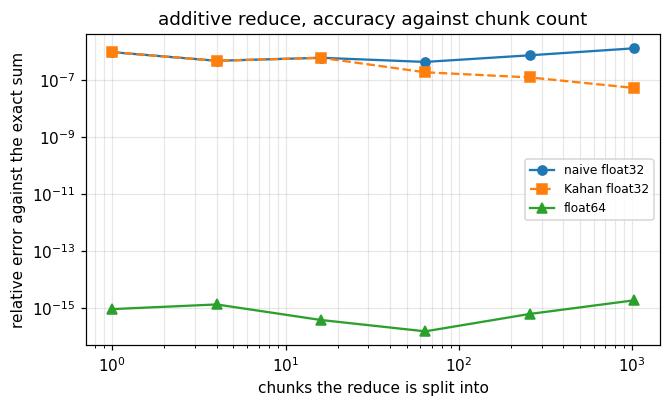

In [7]:
fig, ax = plt.subplots(figsize=(6.2, 3.8))
for column, style, label in [("naive float32 rel err", "o-", "naive float32"),
                             ("Kahan float32 rel err", "s--", "Kahan float32"),
                             ("float64 rel err", "^-", "float64")]:
    ax.loglog(numerics["# chunks"], numerics[column], style, label=label)
ax.set_xlabel("chunks the reduce is split into")
ax.set_ylabel("relative error against the exact sum")
ax.set_title("additive reduce, accuracy against chunk count")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

In [8]:
worst_f32 = numerics["naive float32 rel err"].max()
worst_f64 = numerics["float64 rel err"].max()
naive_last = float(numerics["naive float32 rel err"].iloc[-1])
kahan_last = float(numerics["Kahan float32 rel err"].iloc[-1])
f64_last = float(numerics["float64 rel err"].iloc[-1])
same_worst = numerics.loc[numerics["Kahan float32 rel err"]
                          == numerics["naive float32 rel err"], "# chunks"].tolist()
untouched = numerics.loc[numerics["coefficients the compensation leaves untouched"]
                         == basis.n_coef, "# chunks"].tolist()
better = numerics.loc[numerics["Kahan float32 rel err"]
                      < numerics["naive float32 rel err"], "# chunks"].tolist()
same_worst = [c for c in same_worst if c not in untouched]
# fails if float32 does not degrade past float64's accuracy
assert worst_f32 > 100 * worst_f64
# fails if the compensated sum is ever worse than the naive one, chunk for
# chunk, as it is when the compensation is carried with the wrong sign
# (comp = z - (t - S))
assert (numerics["Kahan float32 rel err"] <= numerics["naive float32 rel err"] * 1.001).all()
# fails if the compensation never improves on the naive sum at any chunk count
# tried, as it does not when the kahan branch drops it and adds inc straight
# into S
assert better
print(f"naive float32 stays near {worst_f32:.1e} relative regardless of chunk "
      f"count; float64 stays near machine precision ({worst_f64:.1e}). The "
      f"compensation reaches only the accumulation across chunks: at "
      f"{', '.join(str(c) for c in untouched)} chunk it leaves every one of "
      f"the {basis.n_coef} coefficients bit-identical to the naive sum, at "
      f"{', '.join(str(c) for c in same_worst)} chunks it moves some of them "
      f"but leaves the worst coefficient's error exactly where the naive sum "
      f"leaves it, and only from "
      f"{better[0]} chunks up does it improve on naive float32. At "
      f"{CHUNK_COUNTS[-1]} chunks it reaches {kahan_last:.1e}, "
      f"{naive_last / kahan_last:.0f}x better than naive float32 "
      f"({naive_last:.1e}) and still "
      f"{math.log10(kahan_last / f64_last):.1f} orders of magnitude above "
      f"float64 ({f64_last:.1e}), where naive float32 sits "
      f"{math.log10(naive_last / f64_last):.1f} orders above it.")

naive float32 stays near 1.3e-06 relative regardless of chunk count; float64 stays near machine precision (1.9e-15). The compensation reaches only the accumulation across chunks: at 1 chunk it leaves every one of the 7 coefficients bit-identical to the naive sum, at 4, 16 chunks it moves some of them but leaves the worst coefficient's error exactly where the naive sum leaves it, and only from 64 chunks up does it improve on naive float32. At 1024 chunks it reaches 5.2e-08, 24x better than naive float32 (1.3e-06) and still 7.4 orders of magnitude above float64 (1.9e-15), where naive float32 sits 8.8 orders above it.


In [9]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("22_scale", "numerics", numerics)
    print("wrote experiments/results/22_scale/numerics.csv")

wrote experiments/results/22_scale/numerics.csv


## 3. Memory against record length

The resident route holds the whole `(n, channels)` array and projects it in
one matmul; `ImageStream` never holds more than the current chunk. Both
routes run on the same 32-channel panel, at two record lengths.

In [10]:
MEM_CHUNK = MEM_LENGTHS[-1] // 10


def resident_route(n):
    rng = np.random.default_rng(0)
    xr = np.linspace(*DOMAIN, n)
    Y = rng.standard_normal((n, MEM_CHANNELS))
    Phi = basis.evaluate(u_of(xr, *DOMAIN))
    return Phi.T @ Y


def streamed_route(n, chunk=MEM_CHUNK):
    # positions are built a chunk at a time: the route holds nothing of length n
    rng = np.random.default_rng(0)
    stream = ImageStream("legendre", ORDER, domain=DOMAIN, channels=MEM_CHANNELS)
    step = (DOMAIN[1] - DOMAIN[0]) / (n - 1)
    for lo in range(0, n, chunk):
        hi = min(lo + chunk, n)
        xs = DOMAIN[0] + step * np.arange(lo, hi, dtype=float)
        stream.update(xs, rng.standard_normal((hi - lo, MEM_CHANNELS)))
    return stream.images()


mem_rows = []
for n in MEM_LENGTHS:
    _, mem_res = peak_memory(lambda n=n: resident_route(n))
    _, mem_str = peak_memory(lambda n=n: streamed_route(n))
    mem_rows.append({"n": n, "channels": MEM_CHANNELS,
                      "resident peak (MiB)": mem_res, "streamed peak (MiB)": mem_str})
memory = pd.DataFrame(mem_rows)
memory

,n,channels,resident peak (MiB),streamed peak (MiB)
0,200000,32,67.141556,84.604192
1,1000000,32,335.695753,80.117995


In [11]:
res_small, res_large = memory["resident peak (MiB)"]
str_small, str_large = memory["streamed peak (MiB)"]
ratio_at_large = res_large / str_large
streamed_change = str_large - str_small
position_mib = (MEM_LENGTHS[-1] - MEM_LENGTHS[0]) * 8 / 1024 ** 2
# fails if the streamed peak is not far below the resident one at the larger length
assert ratio_at_large > 3.0
# fails if the streamed peak grows with the record: holding the whole record's
# positions instead of building them per chunk puts this term above a MiB
assert streamed_change < 1.0
# fails if the resident peak does not grow with N
assert res_large > res_small
print(f"at n={MEM_LENGTHS[-1]:,} the streamed peak ({str_large:.1f} MiB) sits "
      f"{ratio_at_large:.1f}x below the resident one ({res_large:.1f} MiB); "
      f"between the two record lengths the streamed peak changes by "
      f"{streamed_change:+.1f} MiB, while the added samples are "
      f"{position_mib:.1f} MiB of positions alone and the resident peak grows "
      f"by {100 * (res_large / res_small - 1):+.0f}%.")


at n=1,000,000 the streamed peak (80.1 MiB) sits 4.2x below the resident one (335.7 MiB); between the two record lengths the streamed peak changes by -4.5 MiB, while the added samples are 6.1 MiB of positions alone and the resident peak grows by +400%.


In [12]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("22_scale", "memory", memory)
    print("wrote experiments/results/22_scale/memory.csv")

wrote experiments/results/22_scale/memory.csv


## 4. Throughput: fit_many over processes and threads

`fit_many` fans `N_PROBLEMS` independent exponential-decay fits across a
process pool (`backend="loky"`) or a thread pool (`backend="threading"`).
Each configuration is timed over several repeats after a warm-up call that
pays the pool start-up cost outside them, so what the table holds is
steady-state throughput. The BLAS thread count the setup cell prints is 1,
so a thread pool here competes with no threads inside the fits.

In [13]:
rng = np.random.default_rng(1)
problems = []
for _ in range(N_PROBLEMS):
    a, b = rng.uniform(1.0, 3.0), rng.uniform(1.0, 4.0)
    xt = np.linspace(0.0, 1.0, 300)
    yt = a * np.exp(-b * xt) + rng.normal(0.0, 0.02, 300)
    problems.append(FittingProblem(x=xt, y=yt, expr="a*exp(-b*t)", var="t",
                                    method="legendre", kwargs=dict(p0=[1.0, 1.0])))


def timed(n_jobs, backend):
    # a warm-up call pays each backend's pool start-up cost once, outside
    # the timed repeats, so the comparison is steady-state throughput
    results = fit_many(problems, n_jobs=n_jobs, backend=backend)
    times = []
    for _ in range(TIMING_REPS):
        t0 = time.perf_counter()
        results = fit_many(problems, n_jobs=n_jobs, backend=backend)
        times.append(time.perf_counter() - t0)
    return times, results


configs = [(1, "loky", "serial"), (4, "loky", "4 processes"),
           (12, "loky", "12 processes"), (4, "threading", "4 threads")]
throughput_rows = []
all_results = []
for n_jobs, backend, label in configs:
    times, results = timed(n_jobs, backend)
    all_results.append(results)
    throughput_rows.append({
        "configuration": label, "median (s)": float(np.median(times)),
        "min (s)": float(np.min(times)), "max (s)": float(np.max(times)),
        "n_problems": N_PROBLEMS, "reps": TIMING_REPS,
    })
throughput = pd.DataFrame(throughput_rows)
throughput

,configuration,median (s),min (s),max (s),n_problems,reps
0,serial,1.971623,1.956293,2.042909,200,5
1,4 processes,0.537071,0.527365,0.546922,200,5
2,12 processes,0.204377,0.194573,0.215918,200,5
3,4 threads,2.217448,2.147952,2.494242,200,5


In [14]:
finite = all(not r.error for results in all_results for r in results)
med = throughput.set_index("configuration")["median (s)"]
lo = throughput.set_index("configuration")["min (s)"]
hi = throughput.set_index("configuration")["max (s)"]
if not QUICK:
    # fails if a process pool does not halve the serial time: running these two
    # configurations with n_jobs=1 leaves them at the serial loop's own time
    assert lo["4 processes"] < lo["serial"] * 0.5
    assert lo["12 processes"] < lo["serial"] * 0.5
    # fails if threads beat the serial loop by more than a tenth, which the GIL
    # should not allow: running this configuration on the loky backend instead
    # of threading turns it into a speed-up
    assert lo["4 threads"] > lo["serial"] * 0.9
# fails if any fit in any configuration failed
assert finite
proc_lo = lo["serial"] / hi["4 processes"]
proc_hi = hi["serial"] / lo["4 processes"]
thread_lo = lo["4 threads"] / hi["serial"]
thread_hi = hi["4 threads"] / lo["serial"]
thread_med = med["4 threads"] / med["serial"]
print(f"medians over {TIMING_REPS} repeats: serial {med['serial']:.2f} s "
      f"({lo['serial']:.2f}-{hi['serial']:.2f}), 4 processes "
      f"{med['4 processes']:.2f} s ({lo['4 processes']:.2f}-{hi['4 processes']:.2f}), "
      f"12 processes {med['12 processes']:.2f} s "
      f"({lo['12 processes']:.2f}-{hi['12 processes']:.2f}), 4 threads "
      f"{med['4 threads']:.2f} s ({lo['4 threads']:.2f}-{hi['4 threads']:.2f}). "
      f"The repeats put the 4-process speed-up between {proc_lo:.1f}x and "
      f"{proc_hi:.1f}x. The thread pool takes {thread_med:.2f}x the serial "
      f"time by the medians, and the widest pairing of the repeats puts it "
      f"{100 * (thread_lo - 1):+.0f} to {100 * (thread_hi - 1):+.0f} percent "
      f"against the serial loop, its fastest repeat against the serial "
      f"loop's slowest and the other way round. Every one of the "
      f"{N_PROBLEMS} fits in every configuration converged with no error.")

medians over 5 repeats: serial 1.97 s (1.96-2.04), 4 processes 0.54 s (0.53-0.55), 12 processes 0.20 s (0.19-0.22), 4 threads 2.22 s (2.15-2.49). The repeats put the 4-process speed-up between 3.6x and 3.9x. The thread pool takes 1.12x the serial time by the medians, and the widest pairing of the repeats puts it +5 to +27 percent against the serial loop, its fastest repeat against the serial loop's slowest and the other way round. Every one of the 200 fits in every configuration converged with no error.


In [15]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("22_scale", "throughput", throughput)
    print("wrote experiments/results/22_scale/throughput.csv")

wrote experiments/results/22_scale/throughput.csv


## 5. The batched projection on the GPU

The projection `S = Phi^T (w Y)` is one GEMM; batching `B` channels turns
it into one matrix product against the whole panel. `cupy` is reached
through `notebook.optional_import`, so this section runs the CPU sweep
either way and adds the GPU columns only where a working GPU backend is
installed. `numpy` here runs inside
`threadpoolctl.threadpool_limits(limits=1)`, so the comparison is against a
single BLAS thread whatever the shell's thread environment says; the thread
count the limiter reports is recorded in the table.

In [16]:
cupy = notebook.optional_import("cupy")
GPU_REPS = max(TIMING_REPS, 7)  # GPU timings are noisier on a shared machine

gpu_rows = []
for B in GPU_WIDTHS:
    xg = np.linspace(*DOMAIN, GPU_N)
    Yg = np.random.default_rng(0).standard_normal((GPU_N, B))
    basis_g = make_basis("legendre", GPU_ORDER)
    Phi_g = basis_g.evaluate(u_of(xg, *DOMAIN))

    def run_numpy():
        return Phi_g.T @ Yg

    with threadpool_limits(limits=1):
        blas_threads = max((p["num_threads"] for p in threadpool_info()
                            if p["user_api"] == "blas"), default=0)
        run_numpy()
        t_numpy = [None] * GPU_REPS
        for i in range(GPU_REPS):
            t0 = time.perf_counter()
            run_numpy()
            t_numpy[i] = time.perf_counter() - t0

    row = {"width B": B, "BLAS threads": blas_threads,
           "numpy median (s)": float(np.median(t_numpy)),
           "numpy min (s)": float(np.min(t_numpy)),
           "numpy max (s)": float(np.max(t_numpy))}

    if cupy is not None:
        Phi_dev = cupy.asarray(Phi_g)
        Yg_dev = cupy.asarray(Yg)

        def run_warm():
            out = Phi_dev.T @ Yg_dev
            cupy.cuda.Stream.null.synchronize()
            return out

        def run_transfer():
            pd_ = cupy.asarray(Phi_g)
            yd_ = cupy.asarray(Yg)
            out = pd_.T @ yd_
            return cupy.asnumpy(out)

        run_warm()
        run_transfer()
        t_warm, t_transfer = [None] * GPU_REPS, [None] * GPU_REPS
        for i in range(GPU_REPS):
            t0 = time.perf_counter()
            run_warm()
            t_warm[i] = time.perf_counter() - t0
            t0 = time.perf_counter()
            run_transfer()
            t_transfer[i] = time.perf_counter() - t0
        for name, samples in [("cupy warm", t_warm),
                              ("cupy with transfer", t_transfer)]:
            row[f"{name} median (s)"] = float(np.median(samples))
            row[f"{name} min (s)"] = float(np.min(samples))
            row[f"{name} max (s)"] = float(np.max(samples))
    else:
        for name in ["cupy warm", "cupy with transfer"]:
            for stat in ["median", "min", "max"]:
                row[f"{name} {stat} (s)"] = float("nan")
    gpu_rows.append(row)

gpu_projection = pd.DataFrame(gpu_rows)
gpu_projection

,width B,BLAS threads,numpy median (s),numpy min (s),numpy max (s),cupy warm median (s),cupy warm min (s),cupy warm max (s),cupy with transfer median (s),cupy with transfer min (s),cupy with transfer max (s)
0,500,1,0.005637,0.005214,0.005796,0.004202,0.004179,0.004221,0.009497,0.009305,0.009995
1,2000,1,0.022253,0.021622,0.023565,0.004239,0.004213,0.004270,0.025646,0.024948,0.027828
2,8000,1,0.092708,0.088369,0.104603,0.016567,0.016485,0.016671,0.100366,0.097066,0.136545


In [17]:
# fails if the numpy leg ran on more than the one BLAS thread it is held to;
# 0 means threadpoolctl sees no BLAS it can cap (Accelerate on macOS)
assert (gpu_projection["BLAS threads"] <= 1).all()

if cupy is None:
    # fails if the CPU sweep itself did not produce a finite time at every width
    assert np.isfinite(gpu_projection["numpy median (s)"]).all()
    print("no cupy backend on this machine: the width sweep above is numpy "
          "only, and the GPU-versus-host-transfer comparison this section "
          "makes could not be measured here. Notebook 35 section 5 carries "
          "the archive-scale confirmation from a machine that has one.")
else:
    numpy_lo = gpu_projection["numpy min (s)"]
    transfer_lo = gpu_projection["cupy with transfer min (s)"]
    warm_lo = gpu_projection["cupy warm min (s)"]
    # fails if, with transfers counted, the fastest cupy run beats the
    # fastest numpy run by more than a tenth at any width, as it does when
    # the device-resident kernel is timed in this slot
    assert (transfer_lo >= numpy_lo * 0.9).all()
    # fails if the device-resident kernel is not at least twice as fast as
    # the single BLAS thread at the widest panel measured, where the two are
    # far enough apart for a loaded machine to keep them apart: projecting
    # the host arrays in its slot puts it at numpy's own time
    assert warm_lo.iloc[-1] < numpy_lo.iloc[-1] * 0.5
    print(gpu_projection.to_string(index=False))
    for i, B in enumerate(gpu_projection["width B"]):
        band_lo = (gpu_projection["cupy with transfer min (s)"].iloc[i]
                   / gpu_projection["numpy max (s)"].iloc[i])
        band_hi = (gpu_projection["cupy with transfer max (s)"].iloc[i]
                   / gpu_projection["numpy min (s)"].iloc[i])
        warm_band_lo = (gpu_projection["cupy warm min (s)"].iloc[i]
                        / gpu_projection["numpy max (s)"].iloc[i])
        warm_band_hi = (gpu_projection["cupy warm max (s)"].iloc[i]
                        / gpu_projection["numpy min (s)"].iloc[i])
        print(f"width {int(B)}: over {GPU_REPS} repeats cupy with the host "
              f"transfer counted takes {band_lo:.2f}x to {band_hi:.2f}x the "
              f"numpy time; the warm kernel takes {warm_band_lo:.2f}x to "
              f"{warm_band_hi:.2f}x.")
    widths = [int(b) for b in gpu_projection["width B"]]
    faster = [int(b) for b in gpu_projection.loc[warm_lo < numpy_lo, "width B"]]
    where = ("every width tried" if faster == widths
             else "widths " + ", ".join(str(b) for b in faster))
    print("With the transfer counted the device is never a clear win over "
          "the single BLAS thread numpy is held to; without it, it is the "
          f"faster of the two at {where}.")

 width B  BLAS threads  numpy median (s)  numpy min (s)  numpy max (s)  cupy warm median (s)  cupy warm min (s)  cupy warm max (s)  cupy with transfer median (s)  cupy with transfer min (s)  cupy with transfer max (s)
     500             1          0.005637       0.005214       0.005796              0.004202           0.004179           0.004221                       0.009497                    0.009305                    0.009995
    2000             1          0.022253       0.021622       0.023565              0.004239           0.004213           0.004270                       0.025646                    0.024948                    0.027828
    8000             1          0.092708       0.088369       0.104603              0.016567           0.016485           0.016671                       0.100366                    0.097066                    0.136545
width 500: over 7 repeats cupy with the host transfer counted takes 1.61x to 1.92x the numpy time; the warm kernel takes 0.72x t

In [18]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("22_scale", "gpu_projection", gpu_projection)
    print("wrote experiments/results/22_scale/gpu_projection.csv")

wrote experiments/results/22_scale/gpu_projection.csv


## 6. The surrogate trap

A structured fit (`a exp(-b t)`) trained on the first half of a record and
extrapolated over the second half is compared against polynomial
least-squares surrogates trained and extrapolated the same way, over a
sweep of degrees that starts at the structured fit's own image order. The
table carries both halves, the training half the two share and the held-out
half they are scored on, and the last column is each surrogate's held-out
RMSE against the structured fit's.

In [19]:
rng = np.random.default_rng(2)
N_TRAP = 2000
x_trap = np.linspace(0.0, 2.0, N_TRAP)
a_t, b_t = 2.0, 1.3
SIGMA_TRAP = 0.01
y_trap = a_t * np.exp(-b_t * x_trap) + rng.normal(0.0, SIGMA_TRAP, N_TRAP)

split = N_TRAP // 2
xf, yf = x_trap[:split], y_trap[:split]
xh, yh = x_trap[split:], y_trap[split:]

r_struct = dfit("a*exp(-b*t)", Original(xf, yf), "t", p0=[1.0, 1.0])
rmse_struct_in = float(np.sqrt(np.mean((r_struct.predict(xf) - yf) ** 2)))
rmse_struct = float(np.sqrt(np.mean((r_struct.predict(xh) - yh) ** 2)))

trap_rows = [{"method": "structured fit (a exp(-b t))",
              "degree/order": r_struct.image_order, "noise sigma": SIGMA_TRAP,
              "in-sample RMSE": rmse_struct_in, "held-out RMSE": rmse_struct,
              "held-out against the structured fit": 1.0}]
for deg in TRAP_DEGREES:
    V = np.vander(xf, deg + 1)
    C = np.linalg.lstsq(V, yf, rcond=None)[0]
    poly_in = float(np.sqrt(np.mean((V @ C - yf) ** 2)))
    poly_out = float(np.sqrt(np.mean((np.vander(xh, deg + 1) @ C - yh) ** 2)))
    trap_rows.append({"method": f"polynomial surrogate (degree {deg})",
                      "degree/order": deg, "noise sigma": SIGMA_TRAP,
                      "in-sample RMSE": poly_in, "held-out RMSE": poly_out,
                      "held-out against the structured fit": poly_out / rmse_struct})
surrogate_trap = pd.DataFrame(trap_rows)
surrogate_trap

,method,degree/order,noise sigma,in-sample RMSE,held-out RMSE,held-out against the structured fit
0,structured fit (a exp(-b t)),2,0.01,0.010127,0.009849,1.000000
1,polynomial surrogate (degree 2),2,0.01,0.012630,0.394633,40.067583
2,polynomial surrogate (degree 3),3,0.01,0.010129,0.173228,17.588036
3,polynomial surrogate (degree 4),4,0.01,0.010115,0.032595,3.309391
4,polynomial surrogate (degree 5),5,0.01,0.010114,0.194377,19.735294
5,polynomial surrogate (degree 6),6,0.01,0.010113,1.685572,171.138072
6,polynomial surrogate (degree 8),8,0.01,0.010109,92.888607,9431.088459


In [20]:
surrogates = surrogate_trap.iloc[1:]
ratios = surrogates["held-out against the structured fit"]
base = surrogates.iloc[0]
in_better = surrogates[surrogates["in-sample RMSE"] <= rmse_struct_in]
best = surrogates.loc[ratios.idxmin()]
worst = surrogates.loc[ratios.idxmax()]
# fails if a surrogate of any degree tried extrapolates within a factor two
# of the structured fit, as every degree does when the surrogates are fitted
# on the whole record instead of its first half
assert (ratios > 2.0).all()
# fails if the surrogate is not the worse fit on the training half at the
# structured fit's own order: reading this row at the highest degree tried
# instead takes the better of the two in sample
assert base["in-sample RMSE"] > rmse_struct_in
print(f"at the structured fit's own order ({int(base['degree/order'])}) the "
      f"surrogate is the worse of the two on the training half as well: "
      f"in-sample RMSE {base['in-sample RMSE']:.5f} against "
      f"{rmse_struct_in:.5f} at noise sigma {SIGMA_TRAP}. At "
      f"{len(in_better)} of the {len(surrogates)} degrees tried it matches or "
      f"beats the structured fit in sample and still fails to extrapolate: "
      f"over the sweep its held-out RMSE runs from {best['held-out RMSE']:.3f} "
      f"at degree {int(best['degree/order'])} to {worst['held-out RMSE']:.1f} "
      f"at degree {int(worst['degree/order'])}, {ratios.min():.1f}x to "
      f"{ratios.max():.0f}x the structured fit's {rmse_struct:.5f}, which is "
      f"flat across the split ({rmse_struct / rmse_struct_in:.2f}x its own "
      f"in-sample error).")

at the structured fit's own order (2) the surrogate is the worse of the two on the training half as well: in-sample RMSE 0.01263 against 0.01013 at noise sigma 0.01. At 4 of the 6 degrees tried it matches or beats the structured fit in sample and still fails to extrapolate: over the sweep its held-out RMSE runs from 0.033 at degree 4 to 92.9 at degree 8, 3.3x to 9431x the structured fit's 0.00985, which is flat across the split (0.97x its own in-sample error).


In [21]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("22_scale", "surrogate_trap", surrogate_trap)
    print("wrote experiments/results/22_scale/surrogate_trap.csv")

wrote experiments/results/22_scale/surrogate_trap.csv


## Findings and limits

The image's additive structure holds to floating-point rounding: merging
eight chunks, in either order, reproduces the whole-data fit (coefficients
to 4.92e-14 relative, parameters to 2.07e-15; reordering the merge moves the
coefficients by 1.16e-12). Dropping one of eight shards costs data, not an
error, and on this record it costs no accuracy either: the fit on the
remaining 875,000 samples moves a and b by 0.01 and 0.02 of one standard
error of the whole-record fit (3.5e-05 and 7.7e-05), which is parity, and
against the true (a, b) the whole-record fit is off by 9.7e-06 and 7.6e-05
where the 7-of-8 fit is off by 9.4e-06 and 7.5e-05. Chunking does not pay in
time: imaging eight chunks of a million-sample record and merging them
takes 0.078 s against 0.045 s whole (medians of five repeats), a ratio the
repeats bracket between 0.9x and 1.8x, so what the reduce buys is exactness
under splitting, not speed against the resident route. No other accumulator
is measured here, so nothing is claimed against one.

The float64 accumulation `Image` actually does stays near machine precision
(1.9e-15) at every chunk count tried, on an integrand chosen to be hard.
Naive float32 does not: it sits near 1.3e-06 regardless of chunk count. The
Kahan compensation reaches only the sum across chunks, so only that part of
what float32 loses comes back. At one chunk it leaves all seven
coefficients bit-identical to the naive sum; at 4 and 16 chunks it moves
some of them but leaves the worst coefficient's error exactly where the
naive sum leaves it; from 64 chunks up it improves, reaching 5.2e-08 at 1024
chunks, 24x better than naive float32 there. That closes the distance to
float64 from 8.8 orders of magnitude to 7.4, in float32 throughout.

`ImageStream` holds memory flat as the record grows where the resident route
does not: at 1,000,000 samples and 32 channels the streamed peak (80.1 MiB)
sits 4.2x below the resident one (335.7 MiB), and between the two record
lengths tried the streamed peak moves by -4.5 MiB while the resident one
grows by +400%. At the shorter record the streamed route is the more
expensive of the two (84.6 against 67.1 MiB): its fixed cost is what buys
the flat growth.

`fit_many` on a process pool beats a serial loop: 1.97 s serial against
0.54 s on 4 processes, a speed-up the repeats put between 3.6x and 3.9x,
and 0.20 s on 12 processes. On a thread pool it does not: 4 threads take
1.12x the serial time by the medians, and the widest pairing of the repeats
runs 5 to 27 percent against the serial loop, a loss across that band and a
speed-up nowhere in it. The GIL owns that, and with
OPENBLAS_NUM_THREADS and OMP_NUM_THREADS at 1 for the run there is no BLAS
thread for the pool to compete with. Every one of the 200 fits in every
configuration converged. Nothing in the image route is a compiled kernel: the
projection `Phi^T Y` is one GEMM through whatever BLAS numpy links, and what
buys throughput above it is the process pool, not a thread pool.

The GPU leg ran on a cupy/CUDA backend present on this machine, against a
numpy leg held to one BLAS thread by `threadpoolctl`. With the host
transfer counted, cupy is not a clear win over that single thread at any
width: by the medians it takes 1.68x, 1.15x and 1.08x the numpy time at
widths 500, 2000 and 8000, and the repeats bracket 1.61x to 1.92x, 1.06x
to 1.29x and 0.93x to 1.55x, the last band crossing parity. The warm
kernel, transfer excluded, is the faster of the two at every width (0.72x
to 0.81x at 500, 0.18x to 0.20x at 2000 and 0.16x to 0.19x at 8000), so the projection is a device win only once the
data is already there. Notebook 35 section 5 makes the same reading at
archive scale.

A structured fit extrapolates past its training half; a polynomial
surrogate does not, at any degree tried, and how far it falls short is set
by that degree. At the structured fit's own order (2) the surrogate is the
worse of the two on the training half as well, in-sample RMSE 0.01263
against 0.01013 at noise sigma 0.01. At 4 of the 6 degrees tried it matches
or beats the structured fit in sample and still fails out of sample: over
the sweep its held-out RMSE runs from 0.033 at degree 4 to 92.9 at degree 8,
3.3x to 9431x the structured fit's 0.00985, which is itself 0.97x its own
in-sample error. The degree that extrapolates best is still 3.3x the
structured fit's held-out error, on a record with nothing but one
exponential decay in it.

Limits: one machine, with OPENBLAS_NUM_THREADS and OMP_NUM_THREADS at 1 for
the whole run and the GPU section's numpy leg pinned to one BLAS thread by
`threadpoolctl` on top of that; synthetic panels with one signal shape
apiece. The throughput and GPU numbers are wall-clock on a shared machine
and carry the spread printed beside them, not more digits than that; the
GPU numbers are one machine's one GPU, not a general GPU-versus-CPU
verdict. The memory sweep is two record lengths, enough to separate flat
from linear growth and no more. The surrogate comparison is one record and
one polynomial family, swept over degree.

In [22]:
print(notebook.provenance(STARTED))

2026-09-21 commit d3e267d dtfit 0.4.0 dtfit-experimental 0.1.0 42.8s
